# VOS Inference and GT Comparison

This notebook:

1. Downloads the annotated VOS dataset (JPEGImages + Annotations) from Google Drive.
2. Runs `tools/vos_inference.py` to propagate the first-frame GT mask through the video.
3. Visualises predicted masks overlaid on frames, side-by-side with the GT.

## 0. Imports and Environment

In [6]:
import sys
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
from PIL import Image

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


## 1. Download Dataset and Set Paths

Downloads the annotated VOS dataset (`JPEGImages/` and `Annotations/`) from Google Drive.

Skip this section if the data is already present locally.

In [7]:
import os
import shutil
import zipfile
import subprocess
import re

# Root directory where the dataset will be extracted.
DATASET_ROOT = "/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/6_example_dataset"
os.makedirs(DATASET_ROOT, exist_ok=True)

In [8]:

jpeg_dir = os.path.join(DATASET_ROOT, "JPEGImages")
ann_dir  = os.path.join(DATASET_ROOT, "Annotations")
zip_path = os.path.join(DATASET_ROOT, "dataset.zip")

FILE_ID = "1jCTJk6LRsQnCCKe7qJGZnsDLCochzUym"

def gdrive_download(file_id, dest):
    """Download a Google Drive file, handling the virus-scan confirmation page."""
    cookie_file = "/tmp/gdrive_cookies.txt"
    check_html  = "/tmp/gdrive_check.html"

    # Step 1: fetch the confirmation page and save cookies
    subprocess.run([
        "wget", "--quiet",
        "--save-cookies", cookie_file,
        "--keep-session-cookies",
        "--no-check-certificate",
        f"https://drive.google.com/uc?export=download&id={file_id}",
        "-O", check_html,
    ], check=True)

    # Step 2: parse hidden form fields (id, export, confirm, uuid)
    with open(check_html) as f:
        html = f.read()
    params = dict(re.findall(r'name="([^"]+)"\s+value="([^"]*)"', html))

    url = (
        "https://drive.usercontent.google.com/download"
        f"?id={params.get('id', file_id)}"
        f"&export={params.get('export', 'download')}"
        f"&confirm={params.get('confirm', 't')}"
        f"&uuid={params.get('uuid', '')}"
    )

    # Step 3: download the actual file
    subprocess.run([
        "wget", "--show-progress",
        "--load-cookies", cookie_file,
        "--no-check-certificate",
        url, "-O", dest,
    ], check=True)

if not os.path.exists(jpeg_dir) or not os.listdir(jpeg_dir):
    if not os.path.exists(zip_path):
        print("Downloading dataset zip from Google Drive...")
        gdrive_download(FILE_ID, zip_path)
        print("Download complete.")

    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATASET_ROOT)
    os.remove(zip_path)

    # If the zip contained a single top-level folder, flatten it.
    entries = [e for e in os.listdir(DATASET_ROOT) if not e.startswith(".")]
    if entries == [os.path.basename(DATASET_ROOT)] or (
        len(entries) == 1 and os.path.isdir(os.path.join(DATASET_ROOT, entries[0]))
        and not {"JPEGImages", "Annotations"} & set(os.listdir(DATASET_ROOT))
    ):
        inner = os.path.join(DATASET_ROOT, entries[0])
        for item in os.listdir(inner):
            shutil.move(os.path.join(inner, item), DATASET_ROOT)
        os.rmdir(inner)

    print("Extraction complete, zip removed.")
else:
    print(f"Dataset already present in: {DATASET_ROOT}")

# List available video sequences.
video_names = sorted(
    p for p in os.listdir(jpeg_dir)
    if os.path.isdir(os.path.join(jpeg_dir, p))
)
print(f"Found {len(video_names)} video(s): {video_names}")

Dataset already present in: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/6_example_dataset
Found 2 video(s): ['20250515_wheel_148d_refine_1-05152025215505_frame_1091_1166', 'video9_1381_1422']


## 2. Model Configuration

In [9]:
MODEL_CFG    = "../sam2/configs/sam2.1/sam2.1_hiera_b+.yaml"
CHECKPOINT   = "../checkpoints/SAM2_Mice_base_plus.pt"
OUTPUT_DIR   = os.path.join(DATASET_ROOT, "vos_inference_output")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output masks will be saved to: {OUTPUT_DIR}")

Output masks will be saved to: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/6_example_dataset/vos_inference_output


## 3. Run VOS Inference

Uses the first frame's GT annotation as the prompt and propagates it through the whole video.
Output palette-PNG masks are written to `OUTPUT_DIR/<video_name>/`.

In [10]:
from sam2.build_sam import build_sam2_video_predictor
import importlib.util, types

# Import vos_inference helpers directly from tools/.
_spec = importlib.util.spec_from_file_location(
    "vos_inference",
    os.path.abspath(os.path.join(os.getcwd(), "../tools/vos_inference.py")),
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
vos_inference       = _mod.vos_inference
load_masks_from_dir = _mod.load_masks_from_dir

predictor = build_sam2_video_predictor(
    config_file=MODEL_CFG,
    ckpt_path=CHECKPOINT,
    apply_postprocessing=False,
    hydra_overrides_extra=["++model.non_overlap_masks=true"],
)

for n, video_name in enumerate(video_names):
    print(f"\n[{n+1}/{len(video_names)}] {video_name}")
    vos_inference(
        predictor=predictor,
        base_video_dir=jpeg_dir,
        input_mask_dir=ann_dir,
        output_mask_dir=OUTPUT_DIR,
        video_name=video_name,
        score_thresh=0.0,
        use_all_masks=False,
        per_obj_png_file=False,
    )
print("\nInference complete.")

True

[1/2] 20250515_wheel_148d_refine_1-05152025215505_frame_1091_1166


propagate in video: 100%|██████████| 77/77 [00:04<00:00, 19.19it/s]



[2/2] video9_1381_1422


propagate in video: 100%|██████████| 42/42 [00:02<00:00, 15.80it/s]



Inference complete.


## 4. Visualise Predictions vs GT

For each video, displays a grid of frames: original frame | GT mask overlay | predicted mask overlay.

`VIS_STRIDE` controls how many frames are skipped between displayed frames.

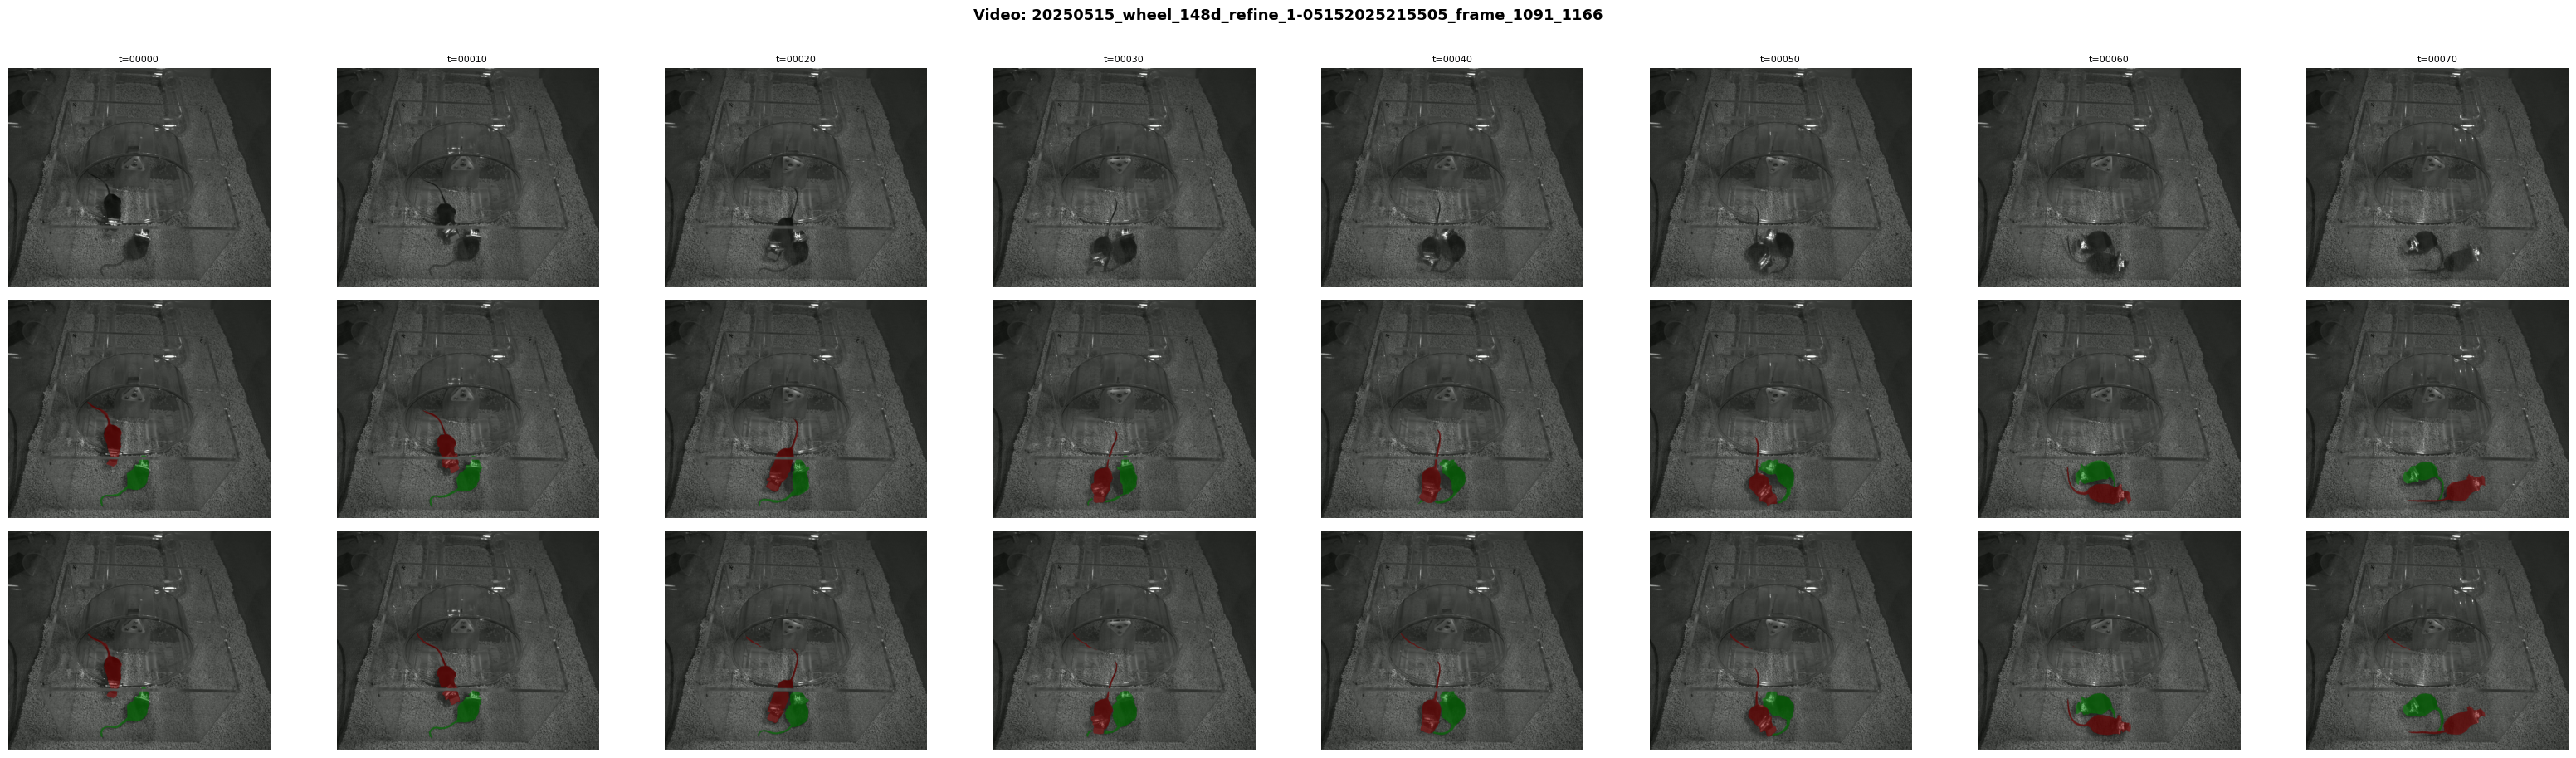

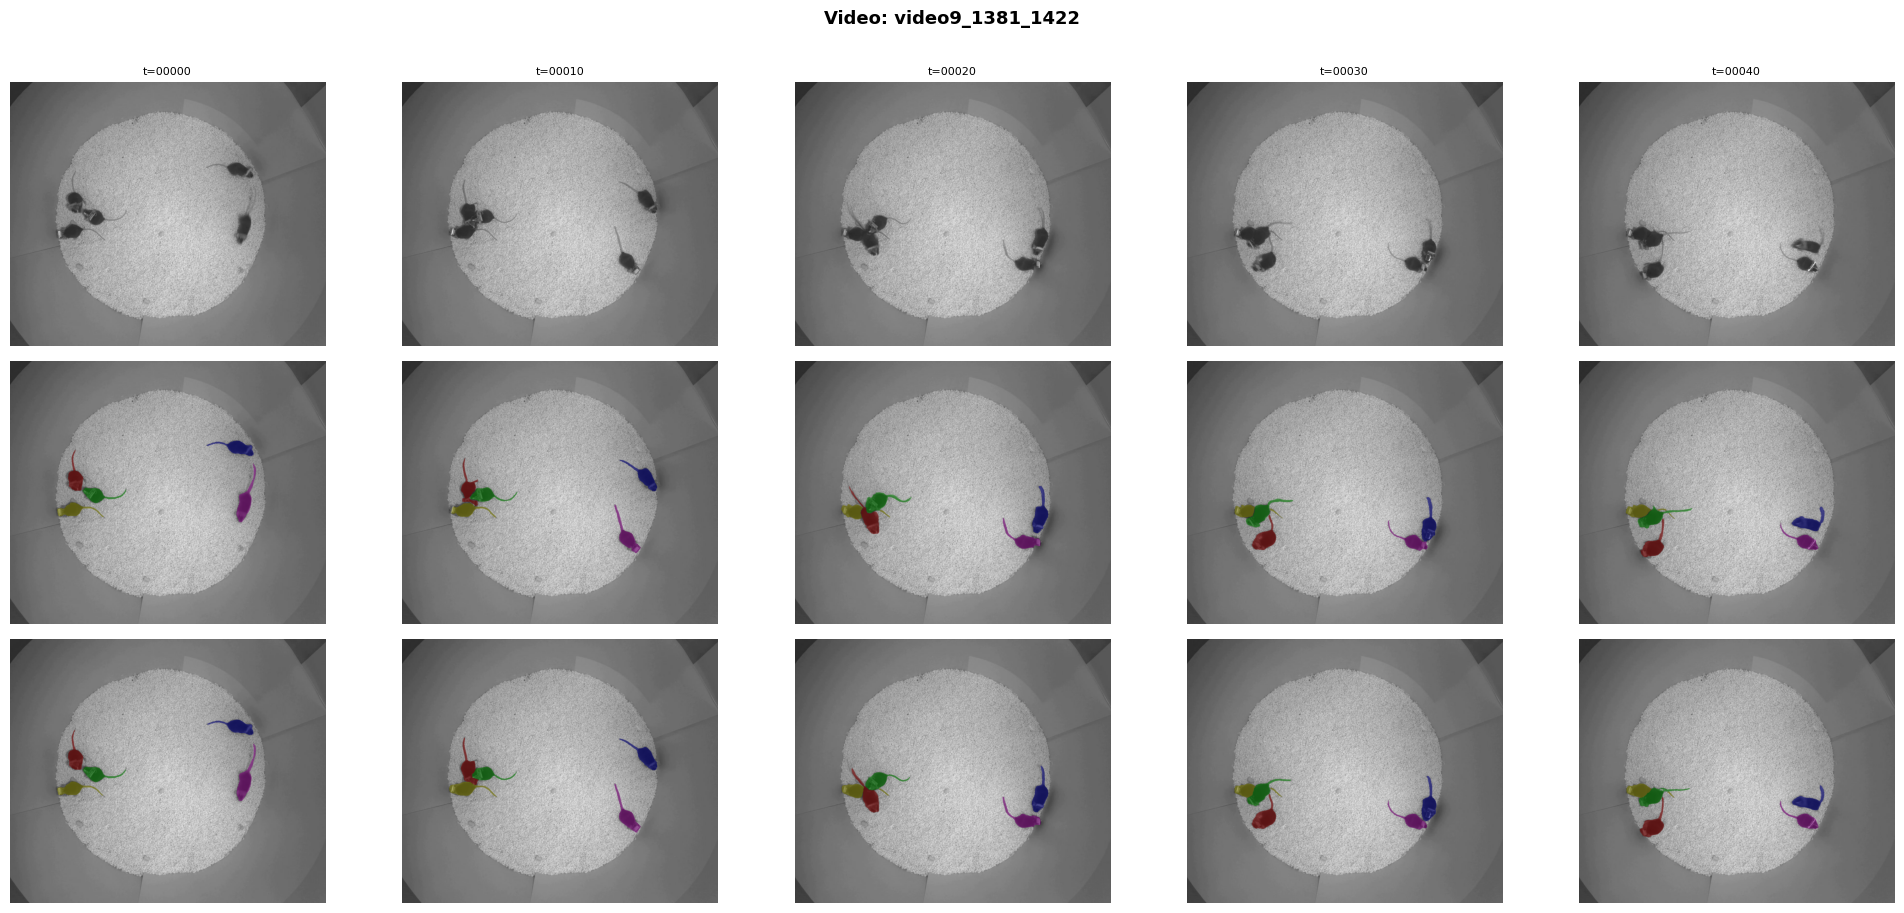

In [11]:
# DAVIS palette — maps object id (1,2,...) to a fixed colour.
PALETTE_BYTES = _mod.DAVIS_PALETTE
PALETTE = np.frombuffer(PALETTE_BYTES, dtype=np.uint8).reshape(-1, 3)  # (256, 3)


def mask_to_rgba(mask_arr, alpha=0.55):
    """Convert a palette-index mask (H,W) to an RGBA overlay."""
    rgba = np.zeros((*mask_arr.shape, 4), dtype=np.float32)
    for obj_id in np.unique(mask_arr):
        obj_id = int(obj_id)   # avoid np.uint8 overflow in modulo
        if obj_id == 0:
            continue
        color = PALETTE[obj_id % len(PALETTE)] / 255.0
        mask_bool = mask_arr == obj_id
        rgba[mask_bool, :3] = color
        rgba[mask_bool,  3] = alpha
    return rgba


def overlay(frame_rgb, mask_arr):
    """Composite a mask overlay onto an RGB frame."""
    out = frame_rgb.astype(np.float32) / 255.0
    ov  = mask_to_rgba(mask_arr)
    a   = ov[..., 3:]
    out = out * (1 - a) + ov[..., :3] * a
    return np.clip(out * 255, 0, 255).astype(np.uint8)


VIS_STRIDE = 10   # show every Nth frame; reduce for denser sampling
MAX_FRAMES = 8    # max frames per video shown in the grid

for video_name in video_names:
    frame_dir  = os.path.join(jpeg_dir, video_name)
    gt_dir     = os.path.join(ann_dir,  video_name)
    pred_dir   = os.path.join(OUTPUT_DIR, video_name)

    frame_files = sorted(
        [f for f in os.listdir(frame_dir) if f.lower().endswith((".jpg", ".jpeg"))],
        key=lambda x: int(os.path.splitext(x)[0]),
    )
    sampled = frame_files[::VIS_STRIDE][:MAX_FRAMES]

    n_cols = len(sampled)
    fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 9))
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    row_labels = ["Frame", "GT", "Prediction"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold")

    for col, fname in enumerate(sampled):
        stem = os.path.splitext(fname)[0]
        frame_rgb = np.array(Image.open(os.path.join(frame_dir, fname)).convert("RGB"))

        gt_path   = os.path.join(gt_dir,   f"{stem}.png")
        pred_path = os.path.join(pred_dir, f"{stem}.png")

        gt_mask   = np.array(Image.open(gt_path))   if os.path.exists(gt_path)   else np.zeros(frame_rgb.shape[:2], np.uint8)
        pred_mask = np.array(Image.open(pred_path)) if os.path.exists(pred_path) else np.zeros(frame_rgb.shape[:2], np.uint8)

        axes[0, col].imshow(frame_rgb)
        axes[1, col].imshow(overlay(frame_rgb, gt_mask))
        axes[2, col].imshow(overlay(frame_rgb, pred_mask))

        axes[0, col].set_title(f"t={stem}", fontsize=8)
        for row in range(3):
            axes[row, col].axis("off")

    fig.suptitle(f"Video: {video_name}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close("all")

## 5. Per-Frame IoU

Computes the mean intersection-over-union (mIoU) per object across all frames and videos.

In [12]:
def compute_iou(pred_mask, gt_mask, obj_id):
    pred = pred_mask == obj_id
    gt   = gt_mask   == obj_id
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred,  gt).sum()
    return float(inter) / float(union) if union > 0 else float("nan")


all_ious = []  # (video, frame, obj_id, iou)

for video_name in video_names:
    gt_dir   = os.path.join(ann_dir,    video_name)
    pred_dir = os.path.join(OUTPUT_DIR, video_name)

    gt_files = sorted(
        [f for f in os.listdir(gt_dir) if f.endswith(".png")],
        key=lambda x: int(os.path.splitext(x)[0]),
    )

    for fname in gt_files:
        stem      = os.path.splitext(fname)[0]
        gt_mask   = np.array(Image.open(os.path.join(gt_dir,   fname)))
        pred_path = os.path.join(pred_dir, fname)
        if not os.path.exists(pred_path):
            continue
        pred_mask = np.array(Image.open(pred_path))

        obj_ids = [oid for oid in np.unique(gt_mask) if oid > 0]
        for oid in obj_ids:
            iou = compute_iou(pred_mask, gt_mask, oid)
            all_ious.append({"video": video_name, "frame": stem, "obj_id": oid, "iou": iou})

# Summary
valid_ious = [r["iou"] for r in all_ious if not np.isnan(r["iou"])]
print(f"Mean IoU across all frames / objects: {np.nanmean(valid_ious):.4f}")

# Per-video summary
for vn in video_names:
    v_ious = [r["iou"] for r in all_ious if r["video"] == vn and not np.isnan(r["iou"])]
    print(f"  {vn}: mean IoU = {np.nanmean(v_ious):.4f}  ({len(v_ious)} samples)")

Mean IoU across all frames / objects: 0.8484
  20250515_wheel_148d_refine_1-05152025215505_frame_1091_1166: mean IoU = 0.8084  (154 samples)
  video9_1381_1422: mean IoU = 0.8777  (210 samples)


### 5.1 IoU over Time

Plots per-object IoU as a function of frame index for each video.

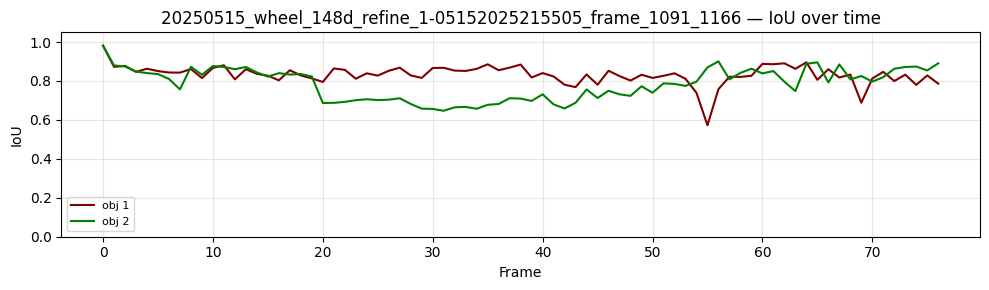

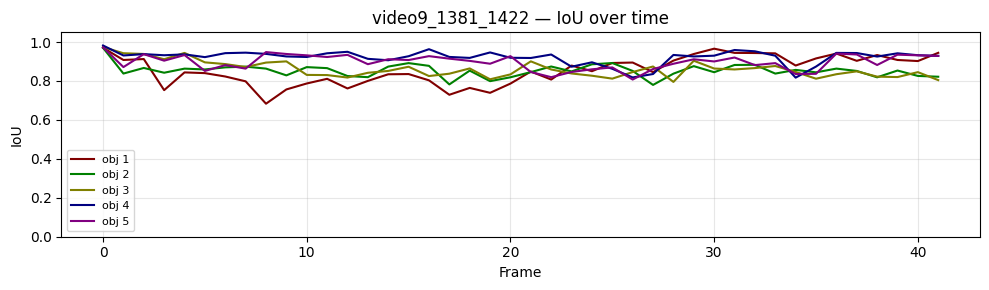

In [13]:
import collections

for video_name in video_names:
    rows = [r for r in all_ious if r["video"] == video_name]
    if not rows:
        continue

    per_obj = collections.defaultdict(lambda: ([], []))
    for r in sorted(rows, key=lambda x: int(x["frame"])):
        frames, ious = per_obj[r["obj_id"]]
        frames.append(int(r["frame"]))
        ious.append(r["iou"])

    fig, ax = plt.subplots(figsize=(10, 3))
    for obj_id, (frames, ious) in sorted(per_obj.items()):
        color = PALETTE[int(obj_id) % len(PALETTE)] / 255.0
        ax.plot(frames, ious, label=f"obj {obj_id}", color=color, linewidth=1.5)

    ax.set_xlabel("Frame")
    ax.set_ylabel("IoU")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{video_name} — IoU over time")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close("all")